In [399]:
import re
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# Функция для извлечения координат из файла
def coordinates_extraction(file_path, is_clinics=True):
    # Регулярное выражение для поиска координат и названий
    if is_clinics:
        pattern = r"([^(]+)\s*\(([-\d.]+),\s*([-\d.]+)\)"
    else:
        pattern = r"([^\(]+)\s*\(([-\d.]+),\s*([-\d.]+)\)"
    
    # Список для хранения координат и названий
    coordinates = []
    
    # Чтение файла
    with open(file_path, 'r', encoding='utf-8') as file:
        # Обрабатываем строки из файла
        for line in file:
            matches = re.findall(pattern, line)
            for match in matches:
                name = match[0].strip()
                x, y = round(float(match[1]), 6), round(float(match[2]), 6)
                coordinates.append([name, x, y])
    
    return coordinates

# Функция для вычисления Евклидова расстояния
def euclidean_distance(p1, p2):
    return np.sqrt(np.sum((np.array(p1) - np.array(p2))**2))

# Функция для обучения нейронной сети Кохонена
def kohonen_network(clinics, weights, learning_rate=0.1, num_epochs=100):

    weights = np.array([[c[1], c[2]] for c in weights])
    # Обучение сети
    for epoch in range(num_epochs):
        learning_rate_epoch = learning_rate * (1 - epoch / num_epochs)  # Уменьшение скорости обучения
        for clinic in clinics:
            
            input_vector = np.array(clinic[1:]) 
            # Вычисляем расстояние от поликлиники до каждого округа
            distances = np.array([euclidean_distance(input_vector, w) for w in weights])
            
            # Нейрон (округ) с минимальным расстоянием побеждает
            winning_neuron = np.argmin(distances)
            
            # Обновление весов победившего нейрона (округа)
            weights[winning_neuron] += learning_rate_epoch * (input_vector - weights[winning_neuron])
    
    return weights

# Функция для кластеризации (определяем победивший нейрон для каждой клиники)
def kohonen_clustering(clinics, weights):
    assignments = []
    for clinic in clinics:
        # Вычисление расстояний между входным вектором и весами нейронов
        distances = np.array([euclidean_distance(clinic[1:], w) for w in weights])  # Используем только координаты (x, y)
        
        # Нейрон с минимальным расстоянием побеждает
        winning_neuron = np.argmin(distances)
        assignments.append(winning_neuron)
    
    return assignments



Итоговые веса:
Центральный АО: [37.614698 55.714491]
Северный АО: [37.525774 55.83839 ]
Северо-Восточный АО: [37.709885 55.872478]
Восточный АО: [37.718286 55.75051 ]
Юго-Восточный АО: [37.847689 55.699251]
Южный АО: [37.65373  55.591132]
Юго-Западный АО: [37.506105 55.538011]
Западный АО: [37.514893 55.67478 ]
Северо-Западный АО: [37.451555 55.82937 ]
Зеленоградский АО: [37.159505 55.976662]
Новомосковский АО: [37.308779 55.441164]
Троицкий АО: [37.077462 55.439974]
Округ                          Поликлиника
------------------------------------------------------------
Центральный АО                 ГБУЗ ГКБ № 1 им.Н.И. Пирогова ДЗМ филиал ЧЛГ для ВВ. Стоматологическое отделение
____________________________________________________________
Северный АО                    Нет назначенных клиник
____________________________________________________________
Северо-Восточный АО            ГАУЗ СП № 32 ДЗМ. Стоматологическое отделение
__________________________________________________________

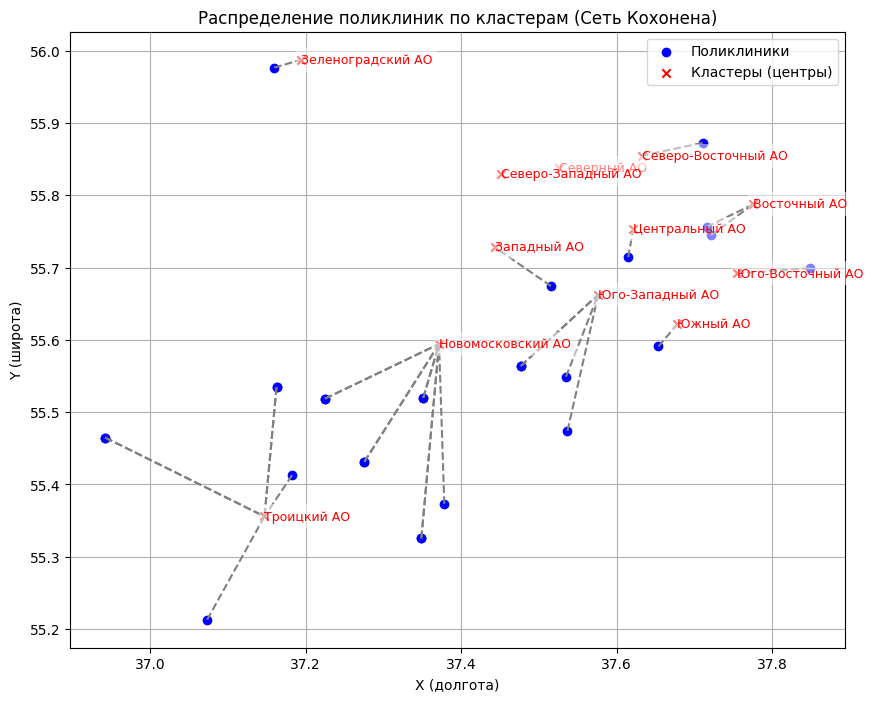

In [400]:
# Открываем файл с данными
clinics_path = "clinics.txt"  # Путь к файлу с координатами клиник
clusters_path = "clusters.txt" # Путь к файлу с координатами кластеров
clinics = coordinates_extraction(clinics_path, is_clinics=True) 
clusters = coordinates_extraction(clusters_path, is_clinics=False)

# Преобразование данных
clinics_coords = np.array([[c[1], c[2]] for c in clinics])
cluster_coords = np.array([[c[1], c[2]] for c in clusters])
cluster_names = [c[0] for c in clusters]

# Кластеризация с обучением нейронной сети Кохонена
weights = kohonen_network(clinics, clusters)

print("\nИтоговые веса:")
for i, weight in enumerate(weights):
    # Округляем каждый компонент веса
    rounded_weight = np.round(weight, 6)
    print(f"{cluster_names[i]}: {rounded_weight}")

# Получаем присвоенные кластеры для каждой клиники  
assignments = kohonen_clustering(clinics, weights)

# # Вывод результатов кластеризации
# print("\nРезультаты кластеризации:")
# for i, cluster_idx in enumerate(assignments):
#     print(f"{clinics[i][0]} -> {clusters[cluster_idx][0]}")


from collections import defaultdict

# Группируем результаты кластеризации: ключ – название округа, значение – список поликлиник
results = defaultdict(list)
for clinic, assignment in zip(clinics, assignments):
    district_name = clusters[assignment][0]
    results[district_name].append(clinic[0])

# Вывод таблицы
print("{:<30} {:<}".format("Округ", "Поликлиника"))
print("-" * 60)
for district in cluster_names:
    clinics_in_district = results.get(district, [])
    if clinics_in_district:
        # Выводим первую строку с округом и первой поликлиникой
        print("{:<30} {:<}".format(district, clinics_in_district[0]))
        # Если поликлиник больше одной, выводим остальные с отступом в столбце округов
        for clinic_name in clinics_in_district[1:]:
            print("{:<30} {:<}".format("", clinic_name))
    else:
        print("{:<30} {:<}".format(district, "Нет назначенных клиник"))
    
    # Разделитель между округами
    print("_" * 60)


# Преобразуем данные поликлиник в numpy-массив для удобства построения
clinics_coords = np.array([[c[1], c[2]] for c in clinics])

# Создаём фигуру
plt.figure(figsize=(10, 8))

# Отображаем поликлиники
plt.scatter(clinics_coords[:, 0], clinics_coords[:, 1],
            c='blue', label='Поликлиники', marker='o')

# Отображаем итоговые координаты кластеров (обученные веса)
plt.scatter(cluster_coords[:, 0], cluster_coords[:, 1],
            c='red', label='Кластеры (центры)', marker='x')

# Подписываем округа (кластеры)
for i, name in enumerate(cluster_names):
    plt.text(cluster_coords[i, 0], cluster_coords[i, 1],
             name, fontsize=9, ha='left', va='center',
             color='red', bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

# Отображаем связи между поликлиниками и округами
for i, clinic in enumerate(clinics):
    winner = assignments[i]
    plt.plot([clinic[1], cluster_coords[winner, 0]], 
             [clinic[2], cluster_coords[winner, 1]], 
             'gray', linestyle='--')

# Настройки графика
plt.title("Распределение поликлиник по кластерам (Сеть Кохонена)")
plt.xlabel("X (долгота)")
plt.ylabel("Y (широта)")
plt.legend()
plt.grid(True)
plt.show()
